# Boundary Conditions and Finite-Size Effects

**Model.** This notebook compares open and periodic SSH chains and tracks finite-size gaps in the transverse-field Ising model.

**Typical uses.** Diagnosing boundary modes, separating edge physics from bulk spectra, checking periodic-boundary conventions, and estimating finite-size effects.

**Parameters.** The SSH cell count $N_c$ and hoppings $t_1$ and $t_2$, set by `n_cells`, `t1`, and `t2`, control edge localization. For the transverse-field Ising model, `n_sites`, `j`, and `h` set the number of spins $N$, Ising coupling $J$, and transverse-field strength $h$.

**Useful plots.** Open/periodic SSH spectra, corresponding lowest-energy probability profiles, and TFIM gap versus system size.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models.models import (
    ssh_edge_state_localizations,
    ssh_model,
    transverse_field_ising,
)
from quantum_lattice_models.plotting import plot_site_probabilities, plot_spectrum
from quantum_lattice_models.spectra import eigensystem, spectral_gap

In [2]:
n_cells = 10
open_ssh = ssh_model(n_cells=n_cells, t1=0.4, t2=1.0, periodic=False)
periodic_ssh = ssh_model(n_cells=n_cells, t1=0.4, t2=1.0, periodic=True)
open_values, open_vectors = eigensystem(open_ssh)
periodic_values, periodic_vectors = eigensystem(periodic_ssh)
open_weights = ssh_edge_state_localizations(open_vectors, n_cells=n_cells, edge_cells=2)
periodic_weights = ssh_edge_state_localizations(periodic_vectors, n_cells=n_cells, edge_cells=2)

open_index = int(np.argmin(np.abs(open_values)))
periodic_index = int(np.argmin(np.abs(periodic_values)))
print("SSH boundary comparison")
print(
    f"  open:     min |E|={abs(open_values[open_index]):.6e}, "
    f"edge weight={open_weights[open_index]:.6f}"
)
print(
    f"  periodic: min |E|={abs(periodic_values[periodic_index]):.6e}, "
    f"edge weight={periodic_weights[periodic_index]:.6f}"
)

SSH boundary comparison
  open:     min |E|=8.808039e-05, edge weight=0.974401
  periodic: min |E|=6.000000e-01, edge weight=0.400000


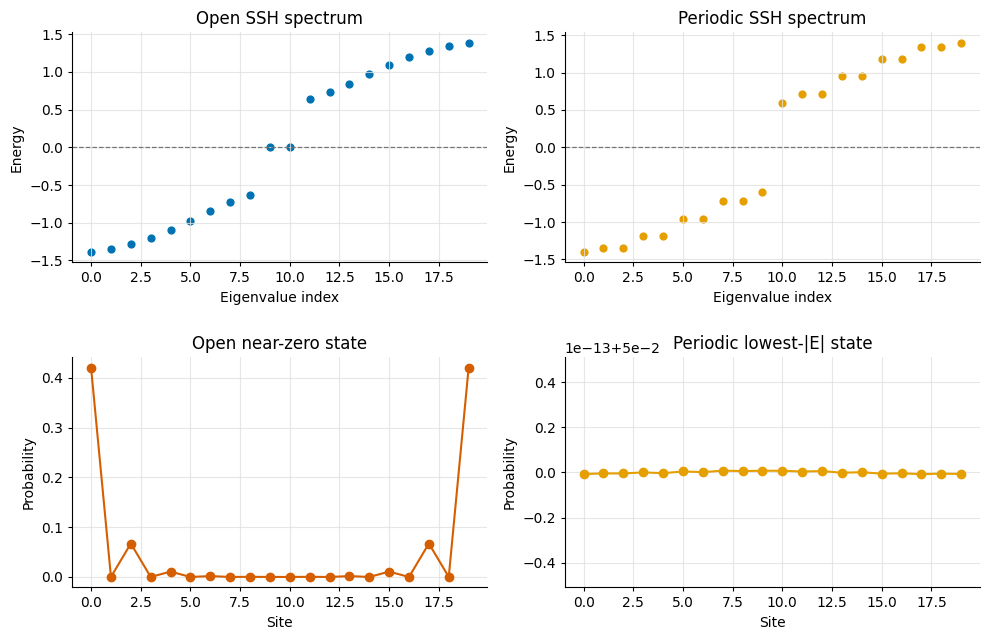

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))
plot_spectrum(open_ssh, ax=axes[0, 0], zero_line=True, color="#0072B2")
axes[0, 0].set_title("Open SSH spectrum")
plot_spectrum(periodic_ssh, ax=axes[0, 1], zero_line=True, color="#E69F00")
axes[0, 1].set_title("Periodic SSH spectrum")
plot_site_probabilities(open_vectors[:, open_index], ax=axes[1, 0], title="Open near-zero state")
plot_site_probabilities(
    periodic_vectors[:, periodic_index],
    ax=axes[1, 1],
    title="Periodic lowest-|E| state",
    color="#E69F00",
)
fig.tight_layout()

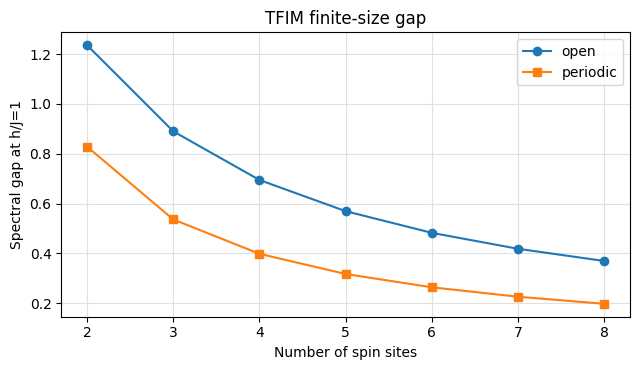

In [4]:
sizes = np.arange(2, 9)
open_gaps = [
    spectral_gap(transverse_field_ising(int(n), j=1.0, h=1.0, periodic=False)) for n in sizes
]
periodic_gaps = [
    spectral_gap(transverse_field_ising(int(n), j=1.0, h=1.0, periodic=True)) for n in sizes
]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(sizes, open_gaps, marker="o", label="open")
ax.plot(sizes, periodic_gaps, marker="s", label="periodic")
ax.set_xlabel("Number of spin sites")
ax.set_ylabel("Spectral gap at h/J=1")
ax.set_title("TFIM finite-size gap")
ax.set_xticks(sizes)
ax.grid(color="0.88", linewidth=0.8)
ax.legend()
fig.tight_layout()